## Practical MCMC

### Autocorrelation Length

The MCMC chain with Metropolis-Hastings will not give fully-independent random samples. The next point is influenced by where the previous point was. We need to check how much to down-sample the chain so that the points lack memory and influence from others. This is given by the **autocorrelation length**. The operation of selecting samples every other autocorrleation lenght is called **thinning**.

### Autocorrelation, ESS, and Thinning



When running a Markov Chain Monte Carlo (MCMC) algorithm, each proposed step fundamentally depends on the previous one. Because of this inherent memory, a chain of $N$ steps does not actually contain $N$ independent pieces of information. To evaluate the true statistical power of our sampling, we rely on the following diagnostic concepts:

**1. Integrated Autocorrelation Time ($\tau$)**
The autocorrelation time, $\tau$, measures the "memory" or "stickiness" of the Markov chain. It represents the number of consecutive steps the algorithm must take before it completely "forgets" its previous position and produces a new, statistically independent sample from the posterior distribution. A highly correlated chain (often caused by a poorly tuned proposal distribution) will have a large $\tau$, meaning it explores the parameter space inefficiently.

**2. Effective Sample Size (ESS)**
The ESS quantifies the actual number of independent, identically distributed (i.i.d.) samples contained within your correlated MCMC chain. It is the true measure of your resolving power and sampling accuracy. If you run a chain for $N$ total steps, the Effective Sample Size is calculated as:

$$\text{ESS} = \frac{N}{\tau}$$

*Note: For robust parameter estimation and stable contour plots, you typically aim for an ESS of at least a few thousand, regardless of how astronomically large $N$ might be.*

**3. Thinning**
Thinning is a data handling technique used to manage the massive memory footprint of long MCMC chains. If $\tau = 50$, storing every single step on your hard drive is heavily redundant because adjacent steps are highly correlated. Thinning a chain by a factor of $k$ means you only save every $k$-th sample (often choosing $k \approx \tau$) and discard the rest. This results in a much lighter, completely independent set of samples without sacrificing any meaningful statistical information.


### Python MCMC Libraries: `emcee` vs `PyMC`

**1. `emcee` (The "Black-Box" Approach)**
* **Algorithm:** *Affine-Invariant Ensemble Sampler*. Uses a group of "walkers" that explore the parameter space by coordinating with each other.
* **How it works:** Treats the physics as a closed box. It only requires an arbitrary Python function that takes parameters as input and returns a single log-probability value.
* **Pros:** Absolute flexibility. Very easy to implement and interfaces perfectly with complex external physical simulators (ODE integrators, C/Fortran libraries).
* **Cons:** Inefficient on high-dimensional problems (starts struggling beyond ~50 parameters).

**2. `PyMC` (The "White-Box" Approach)**
* **Algorithm:** *Hamiltonian Monte Carlo (HMC)* with *NUTS*. Exploits mathematical gradients (slopes) to directionally "slide" toward probability peaks.
* **How it works:** Builds an exact probabilistic graph using the *PyTensor* framework, which allows the library to automatically calculate derivatives (Autodiff).
* **Pros:** Unmatched mathematical efficiency and speed. Effortlessly handles thousands of parameters with a very high acceptance rate.
* **Cons:** Steep learning curve and extremely difficult to make it communicate with "black-box" external physical simulators.

> **Golden Rule:** Use **`emcee`** when you are doing pure computational astrophysics and relying on complex or external numerical models. Use **`PyMC`** when you have known analytical formulas, hierarchical models, or highly dimensional machine learning problems.

#### emcee details: autocorr time, step choice

In emcee this is compute with get_autocorr_time which impose that ESS must be at least around 50, no mattar the value of $\tau$

E come viene fatta la scelta del passo? Implementato in automatico da un algoritmo clamoroso
già interno a run_mcmc che adatta la dimensione del passo. Ad ogni spostamento viene selezionata la direzione che collega un camminatore ad un altro, viene proposta una nuova posizione su questa direzione tramite un fattore scala tra [0.5,2]

Questa proposta può essere accettata o rifiutata; viene accettata se la probabilità della logposterior è maggiore. Se è minore Il camminatore non scarta subito la mossa (altrimenti rimarrebbe incastrato sui picchi locali e non esplorerebbe), ma lancia un dado probabilistico. Più la discesa è ripida, più è probabile che rifiuti la mossa.

### Gibbs Sampling

In the framework of how to sample a posterior, alongside with metropolis-hasting (use in emcee) and hamiltonian monte carlo (used in pymc), we found Gibbs.\
It is an alternative to HMC, it works only for "white box" alogorithm like pymc, meaning has to know the underlying 1D pdf for each parameter.\
Differently from HMC doesn't need to compute gradients but just the value of the 1D pdf at each new point. 100% rate of acceptance.

#### Benefits and Drawbacks


* By drawing directly from the posterior conditionals, the auto-correlation length can be exceptionally small, with **minimal burn-in**.
* It's also **fast**; sequential draws directly from the parameter posterior conditionals means that we are not rejecting any points.
* You need to know the form of the conditional probability distributions for each parameter (or parameter blocks), and how to draw samples from it.
This can be a non-trivial problem, so typically a lot of effort is placed in manipulating the form of the posterior to find a conditional that is a standard probability distribution. This is where **conjugate priors** become really handy.

## The Transient Universe

In [15]:
import numpy as np
import emcee
import matplotlib.pyplot as plt

data = np.load("transient.npy")
time, flux, error = data.T          #homoschedastic errors

In [16]:
# Define the model
def Model(t, b, A, alpha, t0):
    return np.where(t < t0, b, b + A * np.exp(-alpha * (t - t0)))

# Define the log-likelihood
def logLikelihood(theta, t, flux, error):
    b, A, alpha, t0 = theta
    model = Model(t, b, A, alpha, t0)
    logL = -0.5 * np.sum(((flux - model) / error) ** 2)
    return logL

# Define the log-prior
def logPrior(theta):
    b, A, alpha, t0 = theta
    if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
        return -np.log(alpha) 
    return -np.inf

# Define the log-posterior
def logPosterior(theta, t, flux, error):
    logP = logPrior(theta)
    if not np.isfinite(logP):
        return -np.inf
    return logP + logLikelihood(theta, t, flux, error)

  0%|          | 0/2000 [00:00<?, ?it/s]/var/folders/df/8kzdlh4s5fb1h6n2cfc7y5fw0000gn/T/ipykernel_11190/259749542.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 2000/2000 [00:02<00:00, 984.60it/s] 


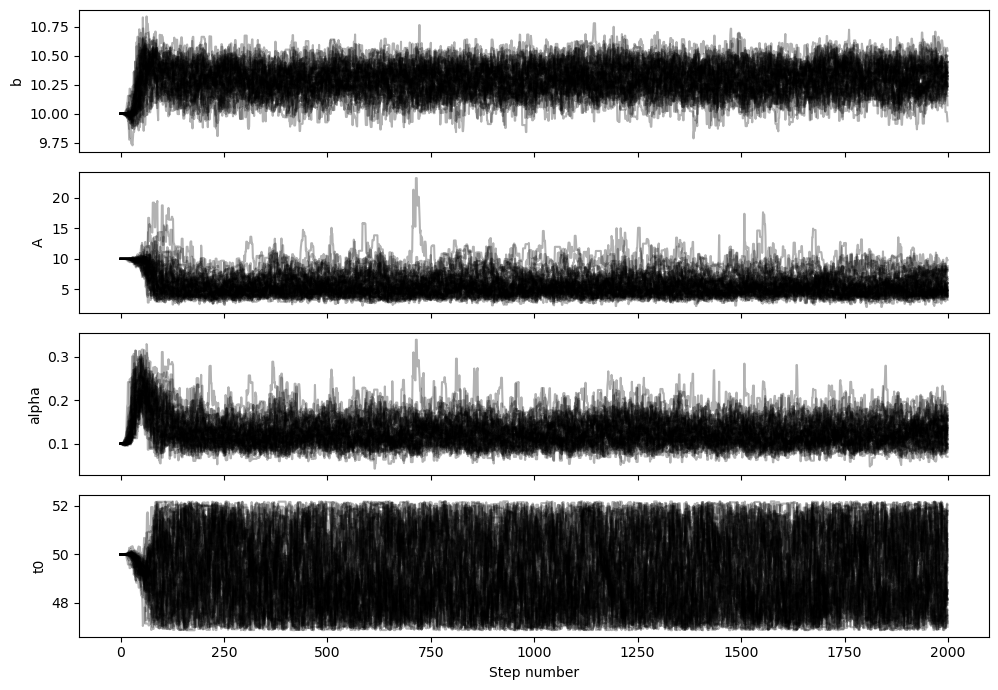

In [17]:
#We need to take into account a thermalization time, thus eliminate all steps made before this time 
#We run a smal test to set the burn and the thinning for the chain.
ndim = 4
nwalkers = 50

nsteps = 2000
try_sempler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))
initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)
try_sempler.run_mcmc(initial_pos, nsteps, progress=True)

traces = try_sempler.get_chain()
labels = ["b", "A", "alpha", "t0"]
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(traces[:, :, i], "k", alpha=0.3)
    ax.set_ylabel(labels[i])
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.show()


  0%|          | 0/10000 [00:00<?, ?it/s]/var/folders/df/8kzdlh4s5fb1h6n2cfc7y5fw0000gn/T/ipykernel_11190/259749542.py:15: RuntimeWarning: invalid value encountered in log
  if 0 < b < 50 and 0 < A < 50 and -5 < np.log(alpha) < 5 and 0 < t0 < 100:
100%|██████████| 10000/10000 [00:09<00:00, 1061.03it/s]


[53.19320019 71.8731457  59.00988855 66.67557414]


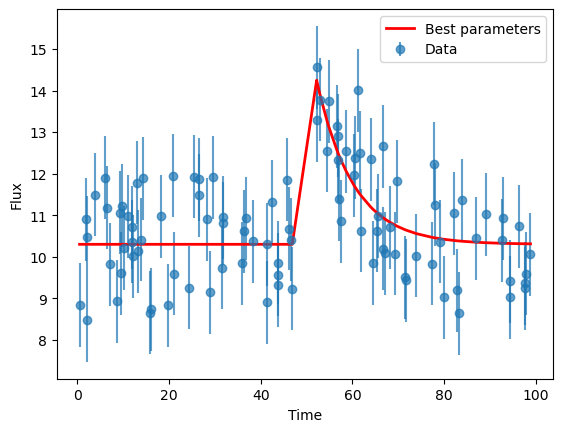

In [18]:
burn = 300          
nsteps = 10000      
sampler = emcee.EnsembleSampler(nwalkers, ndim, logPosterior, args=(time, flux, error))

initial_pos = np.array([10, 10, 0.1, 50]) + 1e-4 * np.random.randn(nwalkers, ndim)
sampler.run_mcmc(initial_pos, nsteps, progress=True)

tau = sampler.get_autocorr_time()
print(tau)
thin = int(np.max(tau) + 1)
samples = sampler.get_chain(discard=burn, thin=thin, flat=True)
# estraggo parametri da catena burnata
best_params = samples.mean(axis=0)

plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
model_flux = Model(time, *best_params)
plt.plot(time, model_flux, 'r-', label='Best parameters', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

(16500, 4)


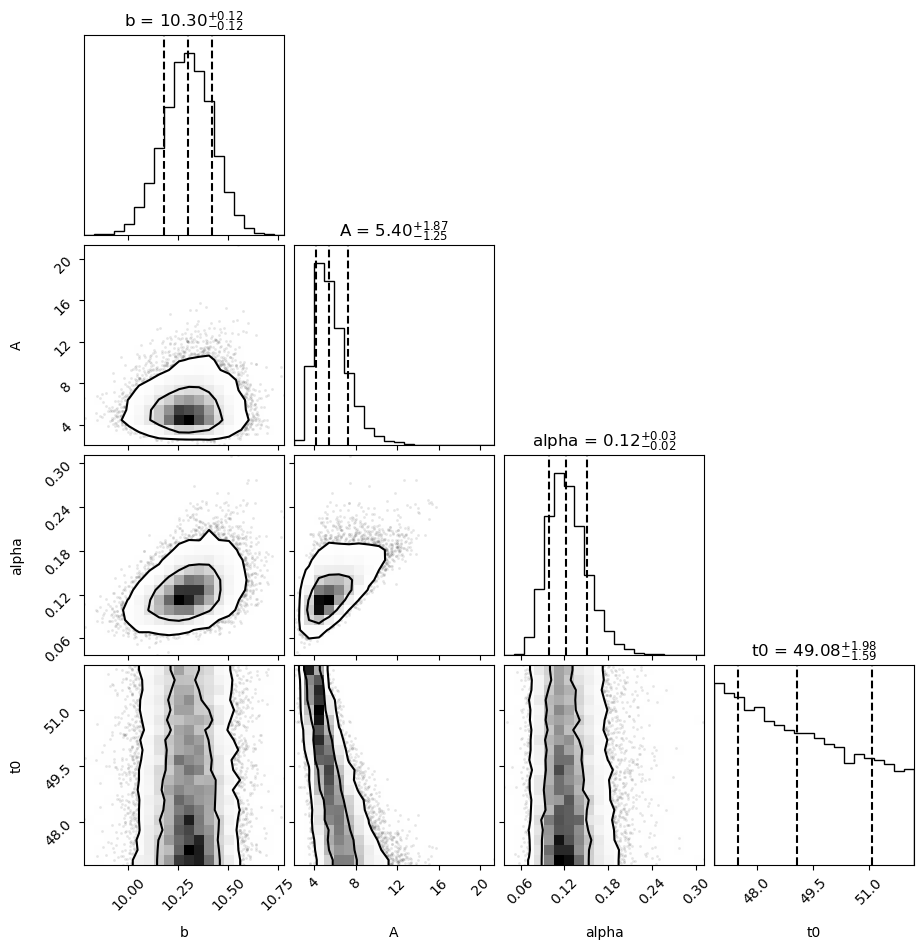

In [19]:
import corner
flat_samples = sampler.get_chain(discard=100, thin=30, flat=True)
print(flat_samples.shape)
fig = corner.corner(flat_samples, labels=labels, levels=[0.68, 0.95], 
                    quantiles=[0.16, 0.5, 0.84], show_titles=True)

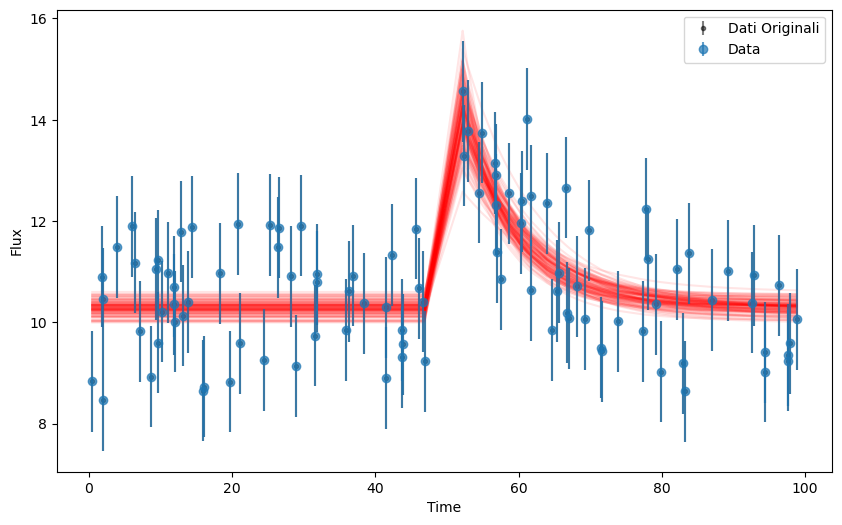

In [20]:
plt.figure(figsize=(10, 6))
plt.errorbar(time, flux, yerr=error, fmt='.k', label='Dati Originali', alpha=0.5, zorder=1)

random_samples = samples[np.random.choice(samples.shape[0], size=100, replace=False)]

for i in range(len(random_samples)):
    y = Model(time, *random_samples[i])
    plt.plot(time, y, 'r-', alpha=0.1)
plt.errorbar(time, flux, yerr=error, fmt='o', label='Data', alpha=0.7)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.legend()
plt.show()

In [23]:
print("\nRISULTATI BAYESIANI (Mediana e 90% Credible Region)")
for i, name in enumerate(labels):
    q5, q50, q95 = np.percentile(flat_samples[:, i], [5, 50, 95])
    
    err_plus = q95 - q50
    err_minus = q50 - q5
    
    print(f"{name:^10} = {q50:8.4f}  +{err_plus:.4f}  -{err_minus:.4f}")

# Estraiamo anche il valore fisico di alpha (non logaritmico) per completezza
alpha_samples = np.exp(flat_samples[:, 2])
q5_a, q50_a, q95_a = np.percentile(alpha_samples, [5, 50, 95])
print(f"\nvalore log{'alpha':^10} = {q50_a:8.4f}  +{q95_a - q50_a:.4f}  -{q50_a - q5_a:.4f}")


RISULTATI BAYESIANI (Mediana e 90% Credible Region)
    b      =  10.2986  +0.1963  -0.2072
    A      =   5.4033  +3.3670  -1.8109
  alpha    =   0.1219  +0.0531  -0.0368
    t0     =  49.0836  +2.7311  -2.0278

valore log  alpha    =   1.1296  +0.0616  -0.0408
